In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../sample_data/DatasetObesity.csv')
print(df.shape)
df.head()


(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
print("valeurs manquantes")
print(df.isnull().sum())
print(f"\nTotal:{df.isnull().sum().sum()} valeurs manquantes")

valeurs manquantes
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total:0 valeurs manquantes


In [ ]:
print("infos générales")
df.info()
print("\n statistiques descriptives ")
df.describe()

infos générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF               

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


=== Distribution des classes ===
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

En pourcentage :
NObeyesdad
Obesity_Type_I         16.6
Obesity_Type_III       15.3
Obesity_Type_II        14.1
Overweight_Level_I     13.7
Overweight_Level_II    13.7
Normal_Weight          13.6
Insufficient_Weight    12.9
Name: proportion, dtype: float64


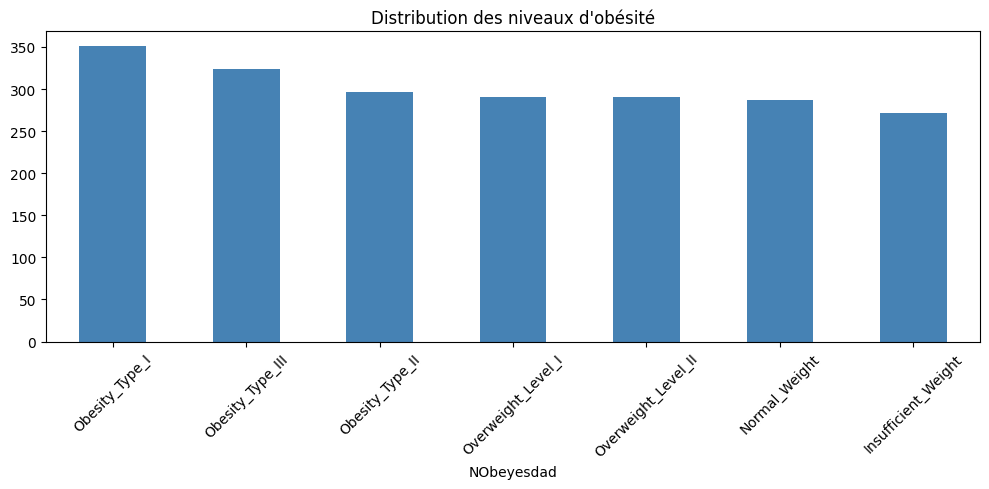

In [ ]:
print("=== Distribution des classes ===")
print(df['NObeyesdad'].value_counts())
print("\nEn pourcentage :")
print(df['NObeyesdad'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(10, 5))
df['NObeyesdad'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution des niveaux d'obésité")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

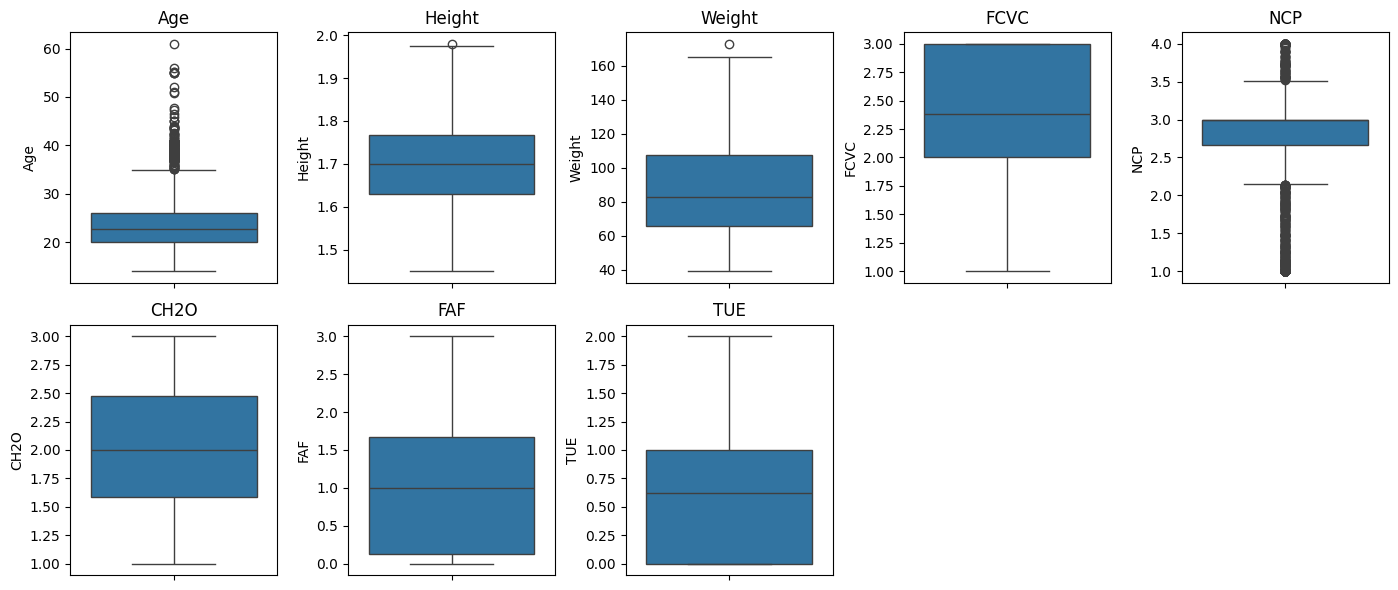

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, len(numerical_cols)//2 + 1, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Optimisation de la mémoire
import numpy as np

def optimize_memory(df):
    """Réduit la taille en mémoire du DataFrame en ajustant les types."""
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Mémoire initiale : {start_mem:.3f} MB")

    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object: # Si ce n'est pas du texte
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32) # On passe en float32 (plus sûr que float16)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Mémoire après optimisation : {end_mem:.3f} MB")
    print(f"Réduction de : {100 * (start_mem - end_mem) / start_mem:.1f}%")
    return df

# On applique la fonction sur notre jeu de données
df_optimized = optimize_memory(df.copy())

Mémoire initiale : 0.274 MB
Mémoire après optimisation : 0.209 MB
Réduction de : 23.5%


In [ ]:
# Vérifier le nombre de doublons
print(f"Nombre de doublons : {df.duplicated().sum()}")

# Afficher les doublons
df[df.duplicated()]

Nombre de doublons : 24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight


In [ ]:
# Supprimer les doublons
df = df.drop_duplicates()

# Vérification
print(f"Shape avant : {df.shape}")
print(f"Doublons restants : {df.duplicated().sum()}")
print("✅ Doublons supprimés !")

Shape avant : (2087, 17)
Doublons restants : 0
✅ Doublons supprimés !


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


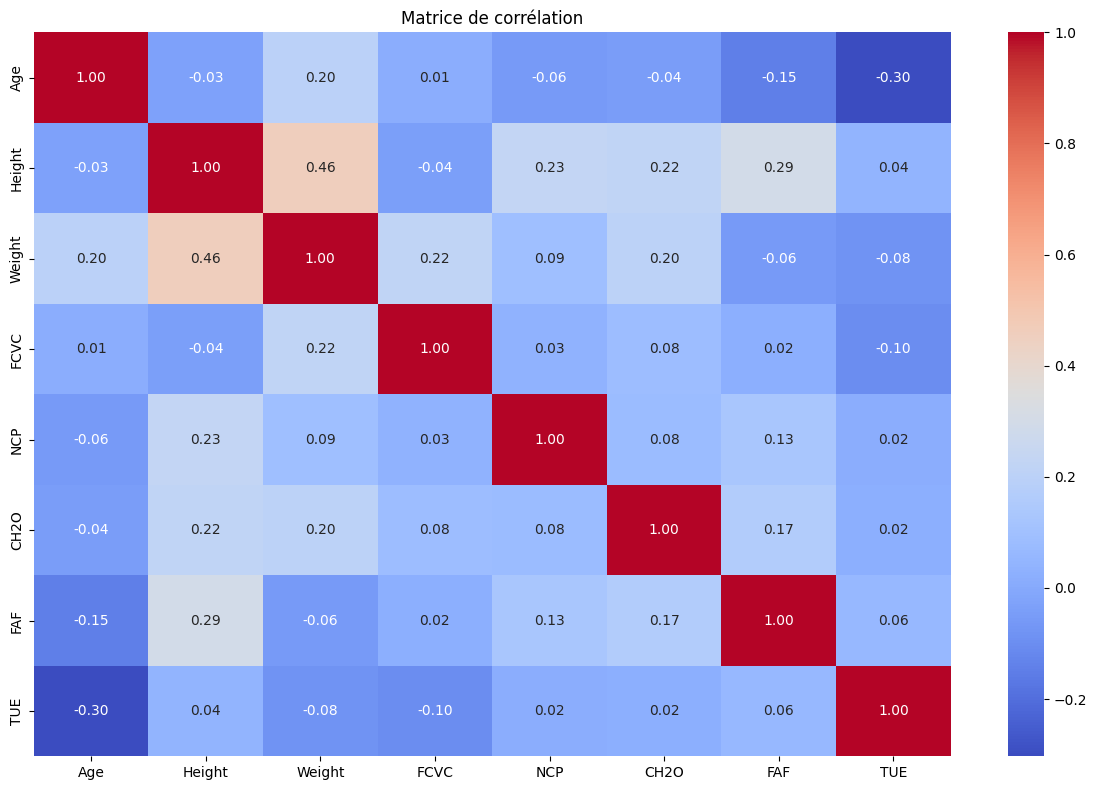

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['float64','int64']).corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Copie de la dataset initiale
df_encoded = df.copy()

# Identifier les colonnes catégorielles
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles : {categorical_cols}\n")

# Encodage
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

print("✅ Encodage terminé !")

Colonnes catégorielles : ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

✅ Encodage terminé !


In [ ]:
print(df_encoded.dtypes)

Gender                              int64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
NObeyesdad                          int64
dtype: object


In [ ]:
print(df_encoded)

      Gender        Age    Height      Weight  family_history_with_overweight  \
0          0  21.000000  1.620000   64.000000                               1   
1          0  21.000000  1.520000   56.000000                               1   
2          1  23.000000  1.800000   77.000000                               1   
3          1  27.000000  1.800000   87.000000                               0   
4          1  22.000000  1.780000   89.800000                               0   
...      ...        ...       ...         ...                             ...   
2106       0  20.976842  1.710730  131.408528                               1   
2107       0  21.982942  1.748584  133.742943                               1   
2108       0  22.524036  1.752206  133.689352                               1   
2109       0  24.361936  1.739450  133.346641                               1   
2110       0  23.664709  1.738836  133.472641                               1   

      FAVC  FCVC  NCP  CAEC

In [ ]:
df_encoded.to_csv('/content/sample_data/ObesityDataSet_encoded.csv', index=False)
print("✅ Dataset encodé sauvegardé !")

✅ Dataset encodé sauvegardé !


In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import os

# 1. Chargement des données encodées
print("Chargement des données...")
# On utilise ton chemin et ton nom de fichier exacts
df = pd.read_csv('/content/sample_data/ObesityDataSet_encoded.csv')

# Le reste du code reste exactement le même !
X = df.drop('NObeyesdad', axis=1)
y_text = df['NObeyesdad']

# 2. Encodage de la cible (Les algorithmes ont besoin de chiffres, pas de texte)
# On transforme les 7 niveaux d'obésité en nombres de 0 à 6
le = LabelEncoder()
y = le.fit_transform(y_text)

# On sauvegarde cet encodeur pour que l'interface Web puisse traduire les chiffres en texte plus tard
os.makedirs('../content/app/models', exist_ok=True)
joblib.dump(le, '../content/app/models/label_encoder.pkl')

# 3. Séparation Train / Test (80% pour apprendre, 20% pour tester)
# 'stratify=y' garantit que les 7 classes sont bien réparties dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialisation des 3 modèles demandés
# On utilise class_weight='balanced' pour gérer le potentiel léger déséquilibre des classes
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
}

# 5. Entraînement et Évaluation
print("\n--- Début de l'entraînement et de l'évaluation ---")
best_model_name = ""
best_f1_score = 0
best_model = None

for name, model in models.items():
    print(f"\nEntraînement de {name}...")
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) # Nécessaire pour le ROC-AUC

    # Calcul des métriques (en mode 'weighted' car on a 7 classes, pas juste 2)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    print(f"Performances de {name} :")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    # On garde en mémoire le modèle avec le meilleur F1-score global
    if f1 > best_f1_score:
        best_f1_score = f1
        best_model_name = name
        best_model = model

# 6. Sauvegarde du modèle final
print(f"\nLe meilleur modèle est {best_model_name} avec un F1-Score de {best_f1_score:.4f}.")
print("Sauvegarde du modèle pour l'interface web...")

# On crée le dossier s'il n'existe pas et on sauvegarde
joblib.dump(best_model, '../content/app/models/best_medical_model.pkl')
print("Modèle sauvegardé sous '../content/app/models/best_medical_model.pkl' !")

Chargement des données...

--- Début de l'entraînement et de l'évaluation ---

Entraînement de Random Forest...
Performances de Random Forest :
Accuracy  : 0.9522
Precision : 0.9556
Recall    : 0.9522
F1-Score  : 0.9530
ROC-AUC   : 0.9973

Entraînement de XGBoost...
Performances de XGBoost :
Accuracy  : 0.9761
Precision : 0.9761
Recall    : 0.9761
F1-Score  : 0.9760
ROC-AUC   : 0.9995

Entraînement de LightGBM...
Performances de LightGBM :
Accuracy  : 0.9761
Precision : 0.9764
Recall    : 0.9761
F1-Score  : 0.9760
ROC-AUC   : 0.9994

Le meilleur modèle est XGBoost avec un F1-Score de 0.9760.
Sauvegarde du modèle pour l'interface web...
Modèle sauvegardé sous '../content/app/models/best_medical_model.pkl' !


In [ ]:
from google.colab import files
files.download('/content/app/models/best_medical_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import os
from sklearn.preprocessing import LabelEncoder

print("--- Recréation du traducteur de classes (Label Encoder) ---")

# 1. On recrée le dossier 'app' au cas où Colab l'aurait effacé
os.makedirs('app', exist_ok=True)

# 2. On recrée l'encodeur avec les 7 classes exactes de ton dataset
le = LabelEncoder()
classes_obosite = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III',
    'Overweight_Level_I',
    'Overweight_Level_II'
]
le.fit(classes_obosite)

# 3. On sauvegarde le fichier au bon endroit
joblib.dump(le, '/content/app/models/label_encoder.pkl')

print("✅ Fichier 'app/label_encoder.pkl' recréé avec succès !")

--- Recréation du traducteur de classes (Label Encoder) ---
✅ Fichier 'app/label_encoder.pkl' recréé avec succès !


--- Génération du Graphique SHAP Global (Format Barres Lisibles) ---


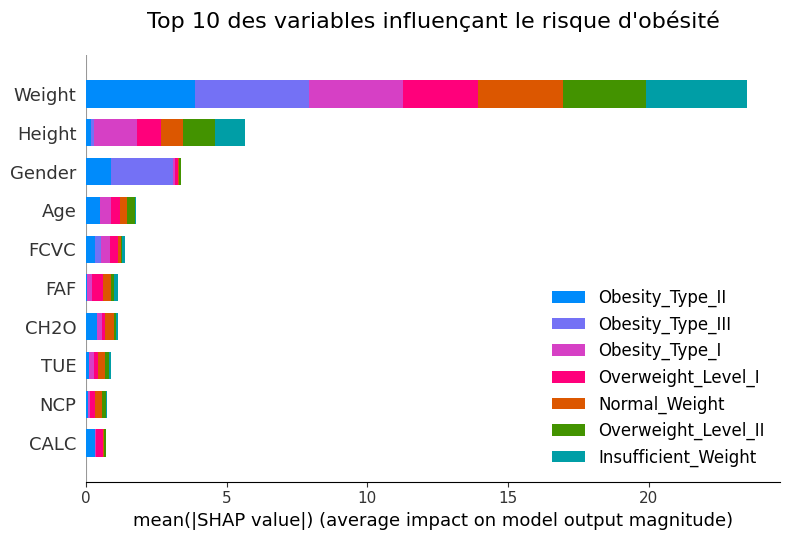

✅ Graphique lisible sauvegardé sous 'app/shap_summary_clear.png' !


In [ ]:
import matplotlib.pyplot as plt
import shap
import os
import joblib


explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)  # ← crée la variable shap_values


print("--- Génération du Graphique SHAP Global (Format Barres Lisibles) ---")

# 1. Vérification du dossier 'app'
os.makedirs('app', exist_ok=True)

# 2. Chargement des noms des classes depuis ton encodeur
le = joblib.load('/content/app/models/label_encoder.pkl')
class_names = list(le.classes_)

# 3. Configuration d'une grande figure pour que le texte soit bien aéré
plt.figure(figsize=(12, 8))

# 4. LE SECRET DE LISIBILITÉ : plot_type="bar"
# Si shap_values est une liste (comme avec Random Forest), cela crée un magnifique graphique empilé
# On limite à max_display=10 pour ne garder que le "Top 10" des variables les plus importantes
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    class_names=class_names,
    max_display=10,
    show=False
)

# 5. Ajout d'un titre professionnel
plt.title("Top 10 des variables influençant le risque d'obésité", fontsize=16, pad=20)

# 6. Ajustement des marges pour ne pas couper le texte
plt.tight_layout()

# 7. Sauvegarde en très haute définition (dpi=300)
plt.savefig('/content/app/static/shap_summary_clear.png', bbox_inches='tight', dpi=300)

# Affichage dans Google Colab
plt.show()

print("✅ Graphique lisible sauvegardé sous 'app/shap_summary_clear.png' !")

In [ ]:
import os
os.makedirs('/content/app/templates', exist_ok=True)
os.makedirs('/content/app/static', exist_ok=True)

# ── 1. Écrire index.html ──────────────────────────────
html_code =""" <!DOCTYPE html>
<html lang="fr">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>ObesityAI — Estimateur de Risque</title>
  <link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=Playfair+Display:wght@600;700&display=swap" rel="stylesheet"/>
  <link rel="stylesheet" href="style.css"/>
</head>
<body>

  <!-- Sidebar Navigation -->
  <aside class="sidebar">
    <div class="sidebar-logo">
      <div class="logo-icon">⚕</div>
      <span>ObesityAI</span>
    </div>
    <nav class="sidebar-nav">
      <a href="#" class="nav-item active">
        <span class="nav-icon">📋</span>
        <span>Évaluation</span>
      </a>
      <a href="#" class="nav-item">
        <span class="nav-icon">📊</span>
        <span>Résultats</span>
      </a>
      <a href="#" class="nav-item">
        <span class="nav-icon">🔬</span>
        <span>Analyse SHAP</span>
      </a>
    </nav>
    <div class="sidebar-footer">
      <p>Centrale Casablanca</p>
      <p>Coding Week 2026</p>
    </div>
  </aside>

  <!-- Main Content -->
  <main class="main">

    <!-- Top Bar -->
    <header class="topbar">
      <div class="topbar-left">
        <h1 class="page-title">Évaluation du Risque d'Obésité</h1>
        <p class="page-subtitle">Renseignez les données du patient pour obtenir une prédiction expliquée</p>
      </div>
      <div class="topbar-right">
        <div class="status-badge">
          <span class="status-dot"></span>
          Modèle LightGBM actif
        </div>
      </div>
    </header>

    <!-- Form -->
    <form id="predictionForm">
      <div class="sections-grid">

        <!-- Section 1 : Infos personnelles -->
        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#fff0f3;">👤</div>
            <div>
              <h2 class="card-title">Informations Personnelles</h2>
              <p class="card-desc">Données démographiques et physiques</p>
            </div>
          </div>

          <div class="fields">
            <div class="field-row">
              <div class="field">
                <label>Genre</label>
                <div class="toggle-group">
                  <input type="radio" name="gender" id="male" value="Male" required/>
                  <label for="male" class="toggle-btn">♂ Homme</label>
                  <input type="radio" name="gender" id="female" value="Female"/>
                  <label for="female" class="toggle-btn">♀ Femme</label>
                </div>
              </div>
            </div>

            <div class="field-row three-cols">
              <div class="field">
                <label for="age">Âge <span class="unit">ans</span></label>
                <input type="number" id="age" name="age" min="1" max="100" placeholder="25" required/>
              </div>
              <div class="field">
                <label for="height">Taille <span class="unit">m</span></label>
                <input type="number" id="height" name="height" step="0.01" min="1" max="2.5" placeholder="1.75" required/>
              </div>
              <div class="field">
                <label for="weight">Poids <span class="unit">kg</span></label>
                <input type="number" id="weight" name="weight" step="0.1" min="10" max="300" placeholder="70" required/>
              </div>
            </div>

            <div class="field">
              <label>Antécédents familiaux d'obésité</label>
              <div class="toggle-group">
                <input type="radio" name="family_history" id="fh_yes" value="yes" required/>
                <label for="fh_yes" class="toggle-btn">✓ Oui</label>
                <input type="radio" name="family_history" id="fh_no" value="no"/>
                <label for="fh_no" class="toggle-btn">✗ Non</label>
              </div>
            </div>
          </div>
        </section>

        <!-- Section 2 : Habitudes alimentaires -->
        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#f0fff4;">🍽️</div>
            <div>
              <h2 class="card-title">Habitudes Alimentaires</h2>
              <p class="card-desc">Comportements nutritionnels du patient</p>
            </div>
          </div>

          <div class="fields">
            <div class="field">
              <label>Consommation fréquente d'aliments caloriques (FAVC)</label>
              <div class="toggle-group">
                <input type="radio" name="favc" id="favc_yes" value="yes" required/>
                <label for="favc_yes" class="toggle-btn">✓ Oui</label>
                <input type="radio" name="favc" id="favc_no" value="no"/>
                <label for="favc_no" class="toggle-btn">✗ Non</label>
              </div>
            </div>

            <div class="field-row two-cols">
              <div class="field">
                <label for="fcvc">Fréquence légumes <span class="unit">1–3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="fcvc" name="fcvc" min="1" max="3" step="0.1" value="2" oninput="updateSlider('fcvc','fcvc_val')"/>
                  <span class="slider-val" id="fcvc_val">2.0</span>
                </div>
              </div>
              <div class="field">
                <label for="ncp">Repas principaux <span class="unit">1–4</span></label>
                <div class="slider-wrap">
                  <input type="range" id="ncp" name="ncp" min="1" max="4" step="0.1" value="3" oninput="updateSlider('ncp','ncp_val')"/>
                  <span class="slider-val" id="ncp_val">3.0</span>
                </div>
              </div>
            </div>

            <div class="field-row two-cols">
              <div class="field">
                <label for="caec">Grignotage entre les repas</label>
                <select id="caec" name="caec" required>
                  <option value="">— Choisir —</option>
                  <option value="no">Jamais</option>
                  <option value="Sometimes">Parfois</option>
                  <option value="Frequently">Fréquemment</option>
                  <option value="Always">Toujours</option>
                </select>
              </div>
              <div class="field">
                <label for="calc">Consommation d'alcool</label>
                <select id="calc" name="calc" required>
                  <option value="">— Choisir —</option>
                  <option value="no">Jamais</option>
                  <option value="Sometimes">Parfois</option>
                  <option value="Frequently">Fréquemment</option>
                  <option value="Always">Toujours</option>
                </select>
              </div>
            </div>
          </div>
        </section>

        <!-- Section 3 : Mode de vie -->
        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#f0f4ff;">🏃</div>
            <div>
              <h2 class="card-title">Mode de Vie</h2>
              <p class="card-desc">Activité physique et habitudes quotidiennes</p>
            </div>
          </div>

          <div class="fields">

            <div class="field-row two-cols">
              <div class="field">
                <label>Fumeur</label>
                <div class="toggle-group">
                  <input type="radio" name="smoke" id="smoke_yes" value="yes" required/>
                  <label for="smoke_yes" class="toggle-btn">✓ Oui</label>
                  <input type="radio" name="smoke" id="smoke_no" value="no"/>
                  <label for="smoke_no" class="toggle-btn">✗ Non</label>
                </div>
              </div>
              <div class="field">
                <label>Surveillance des calories</label>
                <div class="toggle-group">
                  <input type="radio" name="scc" id="scc_yes" value="yes" required/>
                  <label for="scc_yes" class="toggle-btn">✓ Oui</label>
                  <input type="radio" name="scc" id="scc_no" value="no"/>
                  <label for="scc_no" class="toggle-btn">✗ Non</label>
                </div>
              </div>
            </div>

            <div class="field-row three-cols">
              <div class="field">
                <label for="ch2o">Eau quotidienne <span class="unit">1–3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="ch2o" name="ch2o" min="1" max="3" step="0.1" value="2" oninput="updateSlider('ch2o','ch2o_val')"/>
                  <span class="slider-val" id="ch2o_val">2.0</span>
                </div>
              </div>
              <div class="field">
                <label for="faf">Activité physique <span class="unit">0–3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="faf" name="faf" min="0" max="3" step="0.1" value="1" oninput="updateSlider('faf','faf_val')"/>
                  <span class="slider-val" id="faf_val">1.0</span>
                </div>
              </div>
              <div class="field">
                <label for="tue">Temps écran <span class="unit">0–2</span></label>
                <div class="slider-wrap">
                  <input type="range" id="tue" name="tue" min="0" max="2" step="0.1" value="1" oninput="updateSlider('tue','tue_val')"/>
                  <span class="slider-val" id="tue_val">1.0</span>
                </div>
              </div>
            </div>

            <div class="field">
              <label for="mtrans">Moyen de transport principal</label>
              <select id="mtrans" name="mtrans" required>
                <option value="">— Choisir —</option>
                <option value="Automobile">🚗 Voiture</option>
                <option value="Bike">🚲 Vélo</option>
                <option value="Motorbike">🏍️ Moto</option>
                <option value="Public_Transportation">🚌 Transport public</option>
                <option value="Walking">🚶 À pied</option>
              </select>
            </div>

          </div>
        </section>

      </div>

      <!-- Submit Button -->
      <div class="submit-wrap">
        <button type="submit" class="btn-predict">
          <span class="btn-icon">🔍</span>
          Analyser et Prédire le Risque d'Obésité
        </button>
      </div>
    </form>

    <!-- Result Section -->
    <section class="result-section" id="resultSection" style="display:none;">
      <div class="result-grid">

        <!-- Prediction Card -->
        <div class="result-card" id="resultCard">
          <div class="result-header">
            <h3>Diagnostic</h3>
            <span class="result-badge" id="resultBadge"></span>
          </div>
          <div class="result-label" id="resultLabel"></div>
          <div class="confidence-bar-wrap">
            <div class="confidence-bar">
              <div class="confidence-fill" id="confidenceFill"></div>
            </div>
            <span class="confidence-text" id="confidenceText"></span>
          </div>
          <p class="result-note">Basé sur les données saisies et le modèle LightGBM entraîné sur le dataset UCI.</p>
        </div>

        <!-- SHAP Card -->
        <div class="shap-card">
          <div class="shap-header">
            <h3>🔬 Facteurs Influençants — Analyse SHAP</h3>
            <p>Les barres <span class="red-txt">rouges</span> augmentent le risque · Les barres <span class="blue-txt">bleues</span> le réduisent</p>
          </div>
          <div class="shap-img-wrap">
            <img id="shapPlot" src="" alt="SHAP Plot"/>
          </div>
        </div>

      </div>
    </section>

    <!-- Error -->
    <div class="error-banner" id="errorBanner" style="display:none;">
      <span>❌</span>
      <span id="errorMsg"></span>
    </div>

  </main>

  <script>
function updateSlider(inputId, valId) {
  var val = parseFloat(document.getElementById(inputId).value).toFixed(1);
  document.getElementById(valId).textContent = val;
}

document.getElementById('predictionForm').addEventListener('submit', function(e) {
  e.preventDefault();

  document.getElementById('resultSection').style.display = 'none';
  document.getElementById('errorBanner').style.display   = 'none';

  var btn = document.querySelector('.btn-predict');
  btn.textContent = 'Analyse en cours...';
  btn.disabled    = true;

  var formData = new FormData(document.getElementById('predictionForm'));

  fetch('https://871f-34-60-14-152.ngrok-free.app/predict', {
    method: 'POST',
    body: formData
  })
  .then(function(response) {
    return response.json();
  })
  .then(function(data) {
    if (data.error) {
      document.getElementById('errorMsg').textContent      = data.error;
      document.getElementById('errorBanner').style.display = 'block';
      return;
    }
    document.getElementById('resultLabel').textContent         = data.prediction;
    document.getElementById('resultBadge').textContent         = data.confidence + '% de confiance';
    document.getElementById('resultBadge').style.background    = data.color + '22';
    document.getElementById('resultBadge').style.color         = data.color;
    document.getElementById('resultCard').style.borderColor    = data.color;
    document.getElementById('confidenceFill').style.width      = data.confidence + '%';
    document.getElementById('confidenceFill').style.background = data.color;
    document.getElementById('confidenceText').textContent      = data.confidence + '%';
    document.getElementById('resultLabel').style.color         = data.color;
    document.getElementById('shapPlot').src                    = 'https://871f-34-60-14-152.ngrok-free.app/static/shap_summary_clear.png';
    document.getElementById('resultSection').style.display     = 'block';
    document.getElementById('resultSection').scrollIntoView({ behavior: 'smooth' });
  })
  .catch(function(err) {
    document.getElementById('errorMsg').textContent      = 'Erreur : ' + err.message;
    document.getElementById('errorBanner').style.display = 'block';
  })
  .finally(function() {
    btn.textContent = 'Analyser et Predire le Risque';
    btn.disabled    = false;
  });
});
</script>

</body>
</html>"""


with open('/content/app/templates/index.html', 'w') as f:
    f.write(html_code)
print("✅ index.html créé !")

# ── 2. Écrire style.css ───────────────────────────────
css_code = """
/* ── Reset & Base ─────────────────────────────────────── */
*, *::before, *::after { margin: 0; padding: 0; box-sizing: border-box; }

:root {
  --primary:     #b5294e;
  --primary-lt:  #fff0f3;
  --bg:          #f7f8fc;
  --surface:     #ffffff;
  --border:      #e8eaf0;
  --text:        #1a1d2e;
  --muted:       #7a7f99;
  --success:     #16a34a;
  --sidebar-w:   240px;
  --radius:      14px;
  --shadow:      0 2px 16px rgba(0,0,0,0.07);
}

html { font-size: 15px; }

body {
  font-family: 'DM Sans', sans-serif;
  background: var(--bg);
  color: var(--text);
  display: flex;
  min-height: 100vh;
}

/* ── Sidebar ──────────────────────────────────────────── */
.sidebar {
  width: var(--sidebar-w);
  background: var(--surface);
  border-right: 1px solid var(--border);
  display: flex;
  flex-direction: column;
  padding: 28px 16px;
  position: fixed;
  top: 0; left: 0; bottom: 0;
  z-index: 100;
}

.sidebar-logo {
  display: flex;
  align-items: center;
  gap: 10px;
  margin-bottom: 36px;
  padding: 0 8px;
}

.logo-icon {
  width: 38px; height: 38px;
  background: var(--primary);
  color: white;
  border-radius: 10px;
  display: flex; align-items: center; justify-content: center;
  font-size: 1.1rem;
}

.sidebar-logo span {
  font-family: 'Playfair Display', serif;
  font-size: 1.15rem;
  font-weight: 700;
  color: var(--text);
}

.sidebar-nav { flex: 1; display: flex; flex-direction: column; gap: 4px; }

.nav-item {
  display: flex; align-items: center; gap: 10px;
  padding: 10px 12px;
  border-radius: 10px;
  text-decoration: none;
  color: var(--muted);
  font-size: 0.88rem;
  font-weight: 500;
  transition: all 0.2s;
}

.nav-item:hover { background: var(--bg); color: var(--text); }
.nav-item.active { background: var(--primary-lt); color: var(--primary); font-weight: 600; }

.nav-icon { font-size: 1rem; }

.sidebar-footer {
  padding: 12px;
  background: var(--bg);
  border-radius: 10px;
  text-align: center;
}
.sidebar-footer p { font-size: 0.75rem; color: var(--muted); line-height: 1.6; }

/* ── Main ─────────────────────────────────────────────── */
.main {
  margin-left: var(--sidebar-w);
  flex: 1;
  padding: 32px 36px;
  max-width: calc(100vw - var(--sidebar-w));
}

/* ── Topbar ───────────────────────────────────────────── */
.topbar {
  display: flex;
  align-items: flex-start;
  justify-content: space-between;
  margin-bottom: 28px;
  gap: 16px;
}

.page-title {
  font-family: 'Playfair Display', serif;
  font-size: 1.7rem;
  font-weight: 700;
  color: var(--text);
  line-height: 1.2;
}

.page-subtitle {
  font-size: 0.88rem;
  color: var(--muted);
  margin-top: 4px;
}

.status-badge {
  display: flex; align-items: center; gap: 8px;
  background: #f0fdf4;
  border: 1px solid #bbf7d0;
  color: var(--success);
  padding: 8px 14px;
  border-radius: 50px;
  font-size: 0.8rem;
  font-weight: 600;
  white-space: nowrap;
}

.status-dot {
  width: 8px; height: 8px;
  background: var(--success);
  border-radius: 50%;
  animation: pulse 2s infinite;
}

@keyframes pulse {
  0%, 100% { opacity: 1; }
  50%       { opacity: 0.4; }
}

/* ── Sections Grid ────────────────────────────────────── */
.sections-grid {
  display: grid;
  grid-template-columns: repeat(3, 1fr);
  gap: 20px;
  margin-bottom: 24px;
}

@media (max-width: 1100px) { .sections-grid { grid-template-columns: 1fr 1fr; } }
@media (max-width: 700px)  { .sections-grid { grid-template-columns: 1fr; } }

/* ── Form Card ────────────────────────────────────────── */
.form-card {
  background: var(--surface);
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 22px;
  box-shadow: var(--shadow);
}

.card-header {
  display: flex; align-items: flex-start; gap: 12px;
  margin-bottom: 20px;
  padding-bottom: 16px;
  border-bottom: 1px solid var(--border);
}

.card-icon {
  width: 40px; height: 40px;
  border-radius: 10px;
  display: flex; align-items: center; justify-content: center;
  font-size: 1.2rem;
  flex-shrink: 0;
}

.card-title {
  font-size: 0.95rem;
  font-weight: 600;
  color: var(--text);
}

.card-desc {
  font-size: 0.78rem;
  color: var(--muted);
  margin-top: 2px;
}

/* ── Fields ───────────────────────────────────────────── */
.fields { display: flex; flex-direction: column; gap: 14px; }

.field-row {
  display: grid;
  gap: 12px;
}
.field-row.two-cols   { grid-template-columns: 1fr 1fr; }
.field-row.three-cols { grid-template-columns: 1fr 1fr 1fr; }

.field { display: flex; flex-direction: column; gap: 6px; }

.field label {
  font-size: 0.78rem;
  font-weight: 600;
  color: var(--muted);
  text-transform: uppercase;
  letter-spacing: 0.04em;
}

.unit {
  font-weight: 400;
  color: #bbb;
  text-transform: none;
}

.field input[type="number"],
.field select {
  padding: 9px 12px;
  border: 1.5px solid var(--border);
  border-radius: 9px;
  font-size: 0.88rem;
  font-family: 'DM Sans', sans-serif;
  color: var(--text);
  background: var(--bg);
  transition: border-color 0.2s, background 0.2s;
  width: 100%;
}

.field input[type="number"]:focus,
.field select:focus {
  outline: none;
  border-color: var(--primary);
  background: white;
}

/* ── Toggle Group ─────────────────────────────────────── */
.toggle-group {
  display: flex;
  gap: 8px;
  flex-wrap: wrap;
}

.toggle-group input[type="radio"] { display: none; }

.toggle-btn {
  padding: 8px 16px;
  border: 1.5px solid var(--border);
  border-radius: 8px;
  font-size: 0.82rem;
  font-weight: 500;
  color: var(--muted);
  cursor: pointer;
  transition: all 0.15s;
  background: var(--bg);
  user-select: none;
}

.toggle-group input[type="radio"]:checked + .toggle-btn {
  background: var(--primary-lt);
  border-color: var(--primary);
  color: var(--primary);
  font-weight: 600;
}

.toggle-btn:hover {
  border-color: var(--primary);
  color: var(--primary);
}

/* ── Sliders ──────────────────────────────────────────── */
.slider-wrap {
  display: flex; align-items: center; gap: 10px;
}

input[type="range"] {
  flex: 1;
  -webkit-appearance: none;
  height: 4px;
  background: var(--border);
  border-radius: 4px;
  outline: none;
}

input[type="range"]::-webkit-slider-thumb {
  -webkit-appearance: none;
  width: 16px; height: 16px;
  border-radius: 50%;
  background: var(--primary);
  cursor: pointer;
  box-shadow: 0 0 0 3px var(--primary-lt);
  transition: box-shadow 0.2s;
}

input[type="range"]::-webkit-slider-thumb:hover {
  box-shadow: 0 0 0 5px var(--primary-lt);
}

.slider-val {
  font-size: 0.82rem;
  font-weight: 600;
  color: var(--primary);
  min-width: 28px;
  text-align: right;
}

/* ── Submit Button ────────────────────────────────────── */
.submit-wrap { display: flex; justify-content: center; margin-bottom: 32px; }

.btn-predict {
  display: flex; align-items: center; gap: 10px;
  padding: 15px 48px;
  background: var(--primary);
  color: white;
  border: none;
  border-radius: 12px;
  font-size: 0.95rem;
  font-family: 'DM Sans', sans-serif;
  font-weight: 600;
  cursor: pointer;
  transition: transform 0.2s, box-shadow 0.2s, opacity 0.2s;
  box-shadow: 0 4px 20px rgba(181,41,78,0.3);
  letter-spacing: 0.02em;
}

.btn-predict:hover {
  transform: translateY(-2px);
  box-shadow: 0 8px 28px rgba(181,41,78,0.4);
}

.btn-predict:disabled {
  opacity: 0.6;
  cursor: not-allowed;
  transform: none;
}

.btn-icon { font-size: 1.1rem; }

/* ── Result Section ───────────────────────────────────── */
.result-section { animation: fadeUp 0.4s ease; }

@keyframes fadeUp {
  from { opacity: 0; transform: translateY(20px); }
  to   { opacity: 1; transform: translateY(0); }
}

.result-grid {
  display: grid;
  grid-template-columns: 320px 1fr;
  gap: 20px;
  align-items: start;
}

@media (max-width: 900px) { .result-grid { grid-template-columns: 1fr; } }

/* Prediction Card */
.result-card {
  background: var(--surface);
  border: 2px solid var(--border);
  border-radius: var(--radius);
  padding: 24px;
  box-shadow: var(--shadow);
  transition: border-color 0.3s;
}

.result-header {
  display: flex; align-items: center; justify-content: space-between;
  margin-bottom: 16px;
}

.result-header h3 {
  font-size: 0.8rem;
  text-transform: uppercase;
  letter-spacing: 0.08em;
  color: var(--muted);
  font-weight: 600;
}

.result-badge {
  font-size: 0.75rem;
  font-weight: 700;
  padding: 4px 10px;
  border-radius: 50px;
}

.result-label {
  font-family: 'Playfair Display', serif;
  font-size: 1.4rem;
  font-weight: 700;
  margin-bottom: 18px;
  line-height: 1.3;
}

.confidence-bar-wrap {
  display: flex; align-items: center; gap: 10px;
  margin-bottom: 16px;
}

.confidence-bar {
  flex: 1;
  height: 6px;
  background: var(--border);
  border-radius: 6px;
  overflow: hidden;
}

.confidence-fill {
  height: 100%;
  border-radius: 6px;
  transition: width 0.8s ease;
}

.confidence-text {
  font-size: 0.82rem;
  font-weight: 700;
  color: var(--muted);
  min-width: 36px;
}

.result-note {
  font-size: 0.75rem;
  color: var(--muted);
  line-height: 1.5;
  border-top: 1px solid var(--border);
  padding-top: 12px;
  margin-top: 4px;
}

/* SHAP Card */
.shap-card {
  background: var(--surface);
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 24px;
  box-shadow: var(--shadow);
}

.shap-header { margin-bottom: 16px; }
.shap-header h3 { font-size: 0.95rem; font-weight: 600; color: var(--text); margin-bottom: 6px; }
.shap-header p  { font-size: 0.8rem; color: var(--muted); }

.red-txt  { color: #e74c3c; font-weight: 600; }
.blue-txt { color: #3498db; font-weight: 600; }

.shap-img-wrap { border-radius: 10px; overflow: hidden; border: 1px solid var(--border); }
.shap-img-wrap img { width: 100%; display: block; }

/* ── Error Banner ─────────────────────────────────────── */
.error-banner {
  display: flex; align-items: center; gap: 10px;
  background: #fef2f2;
  border: 1px solid #fecaca;
  color: #dc2626;
  padding: 14px 18px;
  border-radius: 10px;
  font-size: 0.88rem;
  font-weight: 500;
  margin-top: 16px;
}

"""

with open('/content/app/static/style.css', 'w') as f:
    f.write(css_code)
print("✅ style.css créé !")

# ── 3. Télécharger les fichiers ───────────────────────
from google.colab import files
files.download('/content/app/templates/index.html')
files.download('/content/app/static/style.css')
print("✅ Fichiers téléchargés !")

✅ index.html créé !
✅ style.css créé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fichiers téléchargés !


In [ ]:
# nouveau
import os
os.makedirs('/content/app/templates', exist_ok=True)
os.makedirs('/content/app/static', exist_ok=True)

NGROK_URL = "https://871f-34-60-14-152.ngrok-free.app"

html_code = """<!DOCTYPE html>
<html lang="fr">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>ObesityAI — Estimateur de Risque</title>
  <link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=Playfair+Display:wght@600;700&display=swap" rel="stylesheet"/>
  <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}"/>
</head>
<body>

  <aside class="sidebar">
    <div class="sidebar-logo">
      <div class="logo-icon">⚕</div>
      <span>ObesityAI</span>
    </div>
    <nav class="sidebar-nav">
      <a href="#" class="nav-item active"><span class="nav-icon">📋</span><span>Évaluation</span></a>
      <a href="#" class="nav-item"><span class="nav-icon">📊</span><span>Résultats</span></a>
      <a href="#" class="nav-item"><span class="nav-icon">🔬</span><span>Analyse SHAP</span></a>
    </nav>
    <div class="sidebar-footer">
      <p>Centrale Casablanca</p>
      <p>Coding Week 2026</p>
    </div>
  </aside>

  <main class="main">
    <header class="topbar">
      <div class="topbar-left">
        <h1 class="page-title">Evaluation du Risque Obesite</h1>
        <p class="page-subtitle">Renseignez les donnees du patient pour obtenir une prediction expliquee</p>
      </div>
      <div class="topbar-right">
        <div class="status-badge">
          <span class="status-dot"></span>
          Modele LightGBM actif
        </div>
      </div>
    </header>

    <form id="predictionForm">
      <div class="sections-grid">

        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#fff0f3;">👤</div>
            <div>
              <h2 class="card-title">Informations Personnelles</h2>
              <p class="card-desc">Donnees demographiques et physiques</p>
            </div>
          </div>
          <div class="fields">
            <div class="field">
              <label>Genre</label>
              <div class="toggle-group">
                <input type="radio" name="gender" id="male" value="Male" required/>
                <label for="male" class="toggle-btn">Homme</label>
                <input type="radio" name="gender" id="female" value="Female"/>
                <label for="female" class="toggle-btn">Femme</label>
              </div>
            </div>
            <div class="field-row three-cols">
              <div class="field">
                <label for="age">Age <span class="unit">ans</span></label>
                <input type="number" id="age" name="age" min="1" max="100" placeholder="25" required/>
              </div>
              <div class="field">
                <label for="height">Taille <span class="unit">m</span></label>
                <input type="number" id="height" name="height" step="0.01" min="1" max="2.5" placeholder="1.75" required/>
              </div>
              <div class="field">
                <label for="weight">Poids <span class="unit">kg</span></label>
                <input type="number" id="weight" name="weight" step="0.1" min="10" max="300" placeholder="70" required/>
              </div>
            </div>
            <div class="field">
              <label>Antecedents familiaux</label>
              <div class="toggle-group">
                <input type="radio" name="family_history" id="fh_yes" value="yes" required/>
                <label for="fh_yes" class="toggle-btn">Oui</label>
                <input type="radio" name="family_history" id="fh_no" value="no"/>
                <label for="fh_no" class="toggle-btn">Non</label>
              </div>
            </div>
          </div>
        </section>

        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#f0fff4;">🍽️</div>
            <div>
              <h2 class="card-title">Habitudes Alimentaires</h2>
              <p class="card-desc">Comportements nutritionnels</p>
            </div>
          </div>
          <div class="fields">
            <div class="field">
              <label>Aliments caloriques (FAVC)</label>
              <div class="toggle-group">
                <input type="radio" name="favc" id="favc_yes" value="yes" required/>
                <label for="favc_yes" class="toggle-btn">Oui</label>
                <input type="radio" name="favc" id="favc_no" value="no"/>
                <label for="favc_no" class="toggle-btn">Non</label>
              </div>
            </div>
            <div class="field-row two-cols">
              <div class="field">
                <label for="fcvc">Legumes <span class="unit">1-3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="fcvc" name="fcvc" min="1" max="3" step="0.1" value="2" oninput="updateSlider('fcvc','fcvc_val')"/>
                  <span class="slider-val" id="fcvc_val">2.0</span>
                </div>
              </div>
              <div class="field">
                <label for="ncp">Repas <span class="unit">1-4</span></label>
                <div class="slider-wrap">
                  <input type="range" id="ncp" name="ncp" min="1" max="4" step="0.1" value="3" oninput="updateSlider('ncp','ncp_val')"/>
                  <span class="slider-val" id="ncp_val">3.0</span>
                </div>
              </div>
            </div>
            <div class="field-row two-cols">
              <div class="field">
                <label for="caec">Grignotage</label>
                <select id="caec" name="caec" required>
                  <option value="">-- Choisir --</option>
                  <option value="no">Jamais</option>
                  <option value="Sometimes">Parfois</option>
                  <option value="Frequently">Frequemment</option>
                  <option value="Always">Toujours</option>
                </select>
              </div>
              <div class="field">
                <label for="calc">Alcool</label>
                <select id="calc" name="calc" required>
                  <option value="">-- Choisir --</option>
                  <option value="no">Jamais</option>
                  <option value="Sometimes">Parfois</option>
                  <option value="Frequently">Frequemment</option>
                  <option value="Always">Toujours</option>
                </select>
              </div>
            </div>
          </div>
        </section>

        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#f0f4ff;">🏃</div>
            <div>
              <h2 class="card-title">Mode de Vie</h2>
              <p class="card-desc">Activite physique et habitudes</p>
            </div>
          </div>
          <div class="fields">
            <div class="field-row two-cols">
              <div class="field">
                <label>Fumeur</label>
                <div class="toggle-group">
                  <input type="radio" name="smoke" id="smoke_yes" value="yes" required/>
                  <label for="smoke_yes" class="toggle-btn">Oui</label>
                  <input type="radio" name="smoke" id="smoke_no" value="no"/>
                  <label for="smoke_no" class="toggle-btn">Non</label>
                </div>
              </div>
              <div class="field">
                <label>Calories (SCC)</label>
                <div class="toggle-group">
                  <input type="radio" name="scc" id="scc_yes" value="yes" required/>
                  <label for="scc_yes" class="toggle-btn">Oui</label>
                  <input type="radio" name="scc" id="scc_no" value="no"/>
                  <label for="scc_no" class="toggle-btn">Non</label>
                </div>
              </div>
            </div>
            <div class="field-row three-cols">
              <div class="field">
                <label for="ch2o">Eau <span class="unit">1-3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="ch2o" name="ch2o" min="1" max="3" step="0.1" value="2" oninput="updateSlider('ch2o','ch2o_val')"/>
                  <span class="slider-val" id="ch2o_val">2.0</span>
                </div>
              </div>
              <div class="field">
                <label for="faf">Activite <span class="unit">0-3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="faf" name="faf" min="0" max="3" step="0.1" value="1" oninput="updateSlider('faf','faf_val')"/>
                  <span class="slider-val" id="faf_val">1.0</span>
                </div>
              </div>
              <div class="field">
                <label for="tue">Ecran <span class="unit">0-2</span></label>
                <div class="slider-wrap">
                  <input type="range" id="tue" name="tue" min="0" max="2" step="0.1" value="1" oninput="updateSlider('tue','tue_val')"/>
                  <span class="slider-val" id="tue_val">1.0</span>
                </div>
              </div>
            </div>
            <div class="field">
              <label for="mtrans">Transport</label>
              <select id="mtrans" name="mtrans" required>
                <option value="">-- Choisir --</option>
                <option value="Automobile">Voiture</option>
                <option value="Bike">Velo</option>
                <option value="Motorbike">Moto</option>
                <option value="Public_Transportation">Transport public</option>
                <option value="Walking">A pied</option>
              </select>
            </div>
          </div>
        </section>

      </div>

      <div class="submit-wrap">
        <button type="button" id="submitBtn" class="btn-predict">
          🔍 Analyser et Predire le Risque
        </button>
      </div>
    </form>

    <section class="result-section" id="resultSection" style="display:none;">
      <div class="result-grid">
        <div class="result-card" id="resultCard">
          <div class="result-header">
            <h3>Diagnostic</h3>
            <span class="result-badge" id="resultBadge"></span>
          </div>
          <div class="result-label" id="resultLabel"></div>
          <div class="confidence-bar-wrap">
            <div class="confidence-bar">
              <div class="confidence-fill" id="confidenceFill"></div>
            </div>
            <span class="confidence-text" id="confidenceText"></span>
          </div>
          <p class="result-note">Base sur les donnees saisies et le modele LightGBM.</p>
        </div>
        <div class="shap-card">
          <div class="shap-header">
            <h3>Facteurs Influencants — SHAP</h3>
            <p>Barres <span class="red-txt">rouges</span> augmentent le risque · Barres <span class="blue-txt">bleues</span> le reduisent</p>
          </div>
          <div class="shap-img-wrap">
            <img id="shapPlot" src="" alt="SHAP Plot"/>
          </div>
        </div>
      </div>
    </section>

    <div class="error-banner" id="errorBanner" style="display:none;">
      <span>❌ </span><span id="errorMsg"></span>
    </div>

  </main>

  <script>
    var NGROK_URL = "https://871f-34-60-14-152.ngrok-free.app";

    function updateSlider(inputId, valId) {
      document.getElementById(valId).textContent =
        parseFloat(document.getElementById(inputId).value).toFixed(1);
    }

    document.getElementById('submitBtn').onclick = function() {

      // Validation manuelle
      var required = ['age','height','weight','caec','calc','mtrans'];
      for (var i = 0; i < required.length; i++) {
        if (!document.getElementById(required[i]).value) {
          alert('Veuillez remplir tous les champs !');
          return;
        }
      }
      if (!document.querySelector('input[name="gender"]:checked')) {
        alert('Veuillez selectionner le genre !'); return;
      }
      if (!document.querySelector('input[name="family_history"]:checked')) {
        alert('Veuillez selectionner les antecedents familiaux !'); return;
      }
      if (!document.querySelector('input[name="favc"]:checked')) {
        alert('Veuillez selectionner FAVC !'); return;
      }
      if (!document.querySelector('input[name="smoke"]:checked')) {
        alert('Veuillez selectionner fumeur !'); return;
      }
      if (!document.querySelector('input[name="scc"]:checked')) {
        alert('Veuillez selectionner SCC !'); return;
      }

      document.getElementById('resultSection').style.display = 'none';
      document.getElementById('errorBanner').style.display   = 'none';

      var btn = document.getElementById('submitBtn');
      btn.textContent = 'Analyse en cours...';
      btn.disabled    = true;

      var formData = new FormData();
      formData.append('gender',         document.querySelector('input[name="gender"]:checked').value);
      formData.append('age',            document.getElementById('age').value);
      formData.append('height',         document.getElementById('height').value);
      formData.append('weight',         document.getElementById('weight').value);
      formData.append('family_history', document.querySelector('input[name="family_history"]:checked').value);
      formData.append('favc',           document.querySelector('input[name="favc"]:checked').value);
      formData.append('fcvc',           document.getElementById('fcvc').value);
      formData.append('ncp',            document.getElementById('ncp').value);
      formData.append('caec',           document.getElementById('caec').value);
      formData.append('smoke',          document.querySelector('input[name="smoke"]:checked').value);
      formData.append('ch2o',           document.getElementById('ch2o').value);
      formData.append('scc',            document.querySelector('input[name="scc"]:checked').value);
      formData.append('faf',            document.getElementById('faf').value);
      formData.append('tue',            document.getElementById('tue').value);
      formData.append('calc',           document.getElementById('calc').value);
      formData.append('mtrans',         document.getElementById('mtrans').value);

      fetch(NGROK_URL + '/predict', {
        method  : 'POST',
        headers : { 'ngrok-skip-browser-warning': 'true' },
        body    : formData
      })
      .then(function(response) { return response.json(); })
      .then(function(data) {
        if (data.error) {
          document.getElementById('errorMsg').textContent      = data.error;
          document.getElementById('errorBanner').style.display = 'block';
          return;
        }
        document.getElementById('resultLabel').textContent         = data.prediction;
        document.getElementById('resultBadge').textContent         = data.confidence + '% de confiance';
        document.getElementById('resultBadge').style.background    = data.color + '22';
        document.getElementById('resultBadge').style.color         = data.color;
        document.getElementById('resultCard').style.borderColor    = data.color;
        document.getElementById('confidenceFill').style.width      = data.confidence + '%';
        document.getElementById('confidenceFill').style.background = data.color;
        document.getElementById('confidenceText').textContent      = data.confidence + '%';
        document.getElementById('resultLabel').style.color         = data.color;
        document.getElementById('shapPlot').src                    = NGROK_URL + '/static/shap_summary_clear.png';
        document.getElementById('resultSection').style.display     = 'block';
        document.getElementById('resultSection').scrollIntoView({ behavior: 'smooth' });
      })
      .catch(function(err) {
        document.getElementById('errorMsg').textContent      = 'Erreur : ' + err.message;
        document.getElementById('errorBanner').style.display = 'block';
      })
      .finally(function() {
        btn.textContent = 'Analyser et Predire le Risque';
        btn.disabled    = false;
      });
    };
  </script>

</body>
</html>"""

with open('/content/app/templates/index.html', 'w') as f:
    f.write(html_code)
print("✅ index.html créé !")

✅ index.html créé !


In [ ]:
#nouveau2
import os
os.makedirs('/content/app/templates', exist_ok=True)
os.makedirs('/content/app/static', exist_ok=True)

NGROK_URL = "https://871f-34-60-14-152.ngrok-free.app"

# ── 1. index.html ─────────────────────────────────────
html_code = """<!DOCTYPE html>
<html lang="fr">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>ObesityAI — Estimateur de Risque</title>
  <link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=Playfair+Display:wght@600;700&display=swap" rel="stylesheet"/>
  <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}"/>
</head>
<body>

  <aside class="sidebar">
    <div class="sidebar-logo">
      <div class="logo-icon">⚕</div>
      <span>ObesityAI</span>
    </div>
    <nav class="sidebar-nav">
      <a href="#" class="nav-item active"><span class="nav-icon">📋</span><span>Evaluation</span></a>
      <a href="#" class="nav-item"><span class="nav-icon">📊</span><span>Resultats</span></a>
      <a href="#" class="nav-item"><span class="nav-icon">🔬</span><span>Analyse SHAP</span></a>
    </nav>
    <div class="sidebar-footer">
      <p>Centrale Casablanca</p>
      <p>Coding Week 2026</p>
    </div>
  </aside>

  <main class="main">
    <header class="topbar">
      <div class="topbar-left">
        <h1 class="page-title">Evaluation du Risque Obesite</h1>
        <p class="page-subtitle">Renseignez les donnees du patient pour obtenir une prediction expliquee</p>
      </div>
      <div class="topbar-right">
        <div class="status-badge">
          <span class="status-dot"></span>
          Modele LightGBM actif
        </div>
      </div>
    </header>

    <form id="predictionForm">
      <div class="sections-grid">

        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#fff0f3;">👤</div>
            <div>
              <h2 class="card-title">Informations Personnelles</h2>
              <p class="card-desc">Donnees demographiques et physiques</p>
            </div>
          </div>
          <div class="fields">
            <div class="field">
              <label>Genre</label>
              <div class="toggle-group">
                <input type="radio" name="gender" id="male" value="Male" required/>
                <label for="male" class="toggle-btn">Homme</label>
                <input type="radio" name="gender" id="female" value="Female"/>
                <label for="female" class="toggle-btn">Femme</label>
              </div>
            </div>
            <div class="field-row three-cols">
              <div class="field">
                <label for="age">Age <span class="unit">ans</span></label>
                <input type="number" id="age" name="age" min="1" max="100" placeholder="25" required/>
              </div>
              <div class="field">
                <label for="height">Taille <span class="unit">m</span></label>
                <input type="number" id="height" name="height" step="0.01" min="1" max="2.5" placeholder="1.75" required/>
              </div>
              <div class="field">
                <label for="weight">Poids <span class="unit">kg</span></label>
                <input type="number" id="weight" name="weight" step="0.1" min="10" max="300" placeholder="70" required/>
              </div>
            </div>
            <div class="field">
              <label>Antecedents familiaux</label>
              <div class="toggle-group">
                <input type="radio" name="family_history" id="fh_yes" value="yes" required/>
                <label for="fh_yes" class="toggle-btn">Oui</label>
                <input type="radio" name="family_history" id="fh_no" value="no"/>
                <label for="fh_no" class="toggle-btn">Non</label>
              </div>
            </div>
          </div>
        </section>

        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#f0fff4;">🍽️</div>
            <div>
              <h2 class="card-title">Habitudes Alimentaires</h2>
              <p class="card-desc">Comportements nutritionnels</p>
            </div>
          </div>
          <div class="fields">
            <div class="field">
              <label>Aliments caloriques (FAVC)</label>
              <div class="toggle-group">
                <input type="radio" name="favc" id="favc_yes" value="yes" required/>
                <label for="favc_yes" class="toggle-btn">Oui</label>
                <input type="radio" name="favc" id="favc_no" value="no"/>
                <label for="favc_no" class="toggle-btn">Non</label>
              </div>
            </div>
            <div class="field-row two-cols">
              <div class="field">
                <label for="fcvc">Legumes <span class="unit">1-3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="fcvc" name="fcvc" min="1" max="3" step="0.1" value="2" oninput="updateSlider('fcvc','fcvc_val')"/>
                  <span class="slider-val" id="fcvc_val">2.0</span>
                </div>
              </div>
              <div class="field">
                <label for="ncp">Repas <span class="unit">1-4</span></label>
                <div class="slider-wrap">
                  <input type="range" id="ncp" name="ncp" min="1" max="4" step="0.1" value="3" oninput="updateSlider('ncp','ncp_val')"/>
                  <span class="slider-val" id="ncp_val">3.0</span>
                </div>
              </div>
            </div>
            <div class="field-row two-cols">
              <div class="field">
                <label for="caec">Grignotage</label>
                <select id="caec" name="caec" required>
                  <option value="">-- Choisir --</option>
                  <option value="no">Jamais</option>
                  <option value="Sometimes">Parfois</option>
                  <option value="Frequently">Frequemment</option>
                  <option value="Always">Toujours</option>
                </select>
              </div>
              <div class="field">
                <label for="calc">Alcool</label>
                <select id="calc" name="calc" required>
                  <option value="">-- Choisir --</option>
                  <option value="no">Jamais</option>
                  <option value="Sometimes">Parfois</option>
                  <option value="Frequently">Frequemment</option>
                  <option value="Always">Toujours</option>
                </select>
              </div>
            </div>
          </div>
        </section>

        <section class="form-card">
          <div class="card-header">
            <div class="card-icon" style="background:#f0f4ff;">🏃</div>
            <div>
              <h2 class="card-title">Mode de Vie</h2>
              <p class="card-desc">Activite physique et habitudes</p>
            </div>
          </div>
          <div class="fields">
            <div class="field-row two-cols">
              <div class="field">
                <label>Fumeur</label>
                <div class="toggle-group">
                  <input type="radio" name="smoke" id="smoke_yes" value="yes" required/>
                  <label for="smoke_yes" class="toggle-btn">Oui</label>
                  <input type="radio" name="smoke" id="smoke_no" value="no"/>
                  <label for="smoke_no" class="toggle-btn">Non</label>
                </div>
              </div>
              <div class="field">
                <label>Calories (SCC)</label>
                <div class="toggle-group">
                  <input type="radio" name="scc" id="scc_yes" value="yes" required/>
                  <label for="scc_yes" class="toggle-btn">Oui</label>
                  <input type="radio" name="scc" id="scc_no" value="no"/>
                  <label for="scc_no" class="toggle-btn">Non</label>
                </div>
              </div>
            </div>
            <div class="field-row three-cols">
              <div class="field">
                <label for="ch2o">Eau <span class="unit">1-3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="ch2o" name="ch2o" min="1" max="3" step="0.1" value="2" oninput="updateSlider('ch2o','ch2o_val')"/>
                  <span class="slider-val" id="ch2o_val">2.0</span>
                </div>
              </div>
              <div class="field">
                <label for="faf">Activite <span class="unit">0-3</span></label>
                <div class="slider-wrap">
                  <input type="range" id="faf" name="faf" min="0" max="3" step="0.1" value="1" oninput="updateSlider('faf','faf_val')"/>
                  <span class="slider-val" id="faf_val">1.0</span>
                </div>
              </div>
              <div class="field">
                <label for="tue">Ecran <span class="unit">0-2</span></label>
                <div class="slider-wrap">
                  <input type="range" id="tue" name="tue" min="0" max="2" step="0.1" value="1" oninput="updateSlider('tue','tue_val')"/>
                  <span class="slider-val" id="tue_val">1.0</span>
                </div>
              </div>
            </div>
            <div class="field">
              <label for="mtrans">Transport</label>
              <select id="mtrans" name="mtrans" required>
                <option value="">-- Choisir --</option>
                <option value="Automobile">Voiture</option>
                <option value="Bike">Velo</option>
                <option value="Motorbike">Moto</option>
                <option value="Public_Transportation">Transport public</option>
                <option value="Walking">A pied</option>
              </select>
            </div>
          </div>
        </section>

      </div>

      <div class="submit-wrap">
        <button type="button" id="submitBtn" class="btn-predict">
          🔍 Analyser et Predire le Risque
        </button>
      </div>
    </form>

    <section class="result-section" id="resultSection" style="display:none;">
      <div class="result-grid">
        <div class="result-card" id="resultCard">
          <div class="result-header">
            <h3>Diagnostic</h3>
            <span class="result-badge" id="resultBadge"></span>
          </div>
          <div class="result-label" id="resultLabel"></div>
          <div class="confidence-bar-wrap">
            <div class="confidence-bar">
              <div class="confidence-fill" id="confidenceFill"></div>
            </div>
            <span class="confidence-text" id="confidenceText"></span>
          </div>
          <p class="result-note">Base sur les donnees saisies et le modele LightGBM.</p>
        </div>
        <div class="shap-card">
          <div class="shap-header">
            <h3>Facteurs Influencants — SHAP</h3>
            <p>Barres <span class="red-txt">rouges</span> augmentent le risque · Barres <span class="blue-txt">bleues</span> le reduisent</p>
          </div>
          <div class="shap-img-wrap">
            <img id="shapPlot" src="" alt="SHAP Plot"/>
          </div>
        </div>
      </div>
    </section>

    <div class="error-banner" id="errorBanner" style="display:none;">
      <span>❌ </span><span id="errorMsg"></span>
    </div>

  </main>

  <script>
    var NGROK_URL = "https://871f-34-60-14-152.ngrok-free.app";

    function updateSlider(inputId, valId) {
      document.getElementById(valId).textContent =
        parseFloat(document.getElementById(inputId).value).toFixed(1);
    }

    document.getElementById('submitBtn').onclick = function() {
      var required = ['age','height','weight','caec','calc','mtrans'];
      for (var i = 0; i < required.length; i++) {
        if (!document.getElementById(required[i]).value) {
          alert('Veuillez remplir tous les champs !'); return;
        }
      }
      if (!document.querySelector('input[name="gender"]:checked'))         { alert('Genre manquant !'); return; }
      if (!document.querySelector('input[name="family_history"]:checked')) { alert('Antecedents manquants !'); return; }
      if (!document.querySelector('input[name="favc"]:checked'))           { alert('FAVC manquant !'); return; }
      if (!document.querySelector('input[name="smoke"]:checked'))          { alert('Fumeur manquant !'); return; }
      if (!document.querySelector('input[name="scc"]:checked'))            { alert('SCC manquant !'); return; }

      document.getElementById('resultSection').style.display = 'none';
      document.getElementById('errorBanner').style.display   = 'none';

      var btn = document.getElementById('submitBtn');
      btn.textContent = 'Analyse en cours...';
      btn.disabled    = true;

      var formData = new FormData();
      formData.append('gender',         document.querySelector('input[name="gender"]:checked').value);
      formData.append('age',            document.getElementById('age').value);
      formData.append('height',         document.getElementById('height').value);
      formData.append('weight',         document.getElementById('weight').value);
      formData.append('family_history', document.querySelector('input[name="family_history"]:checked').value);
      formData.append('favc',           document.querySelector('input[name="favc"]:checked').value);
      formData.append('fcvc',           document.getElementById('fcvc').value);
      formData.append('ncp',            document.getElementById('ncp').value);
      formData.append('caec',           document.getElementById('caec').value);
      formData.append('smoke',          document.querySelector('input[name="smoke"]:checked').value);
      formData.append('ch2o',           document.getElementById('ch2o').value);
      formData.append('scc',            document.querySelector('input[name="scc"]:checked').value);
      formData.append('faf',            document.getElementById('faf').value);
      formData.append('tue',            document.getElementById('tue').value);
      formData.append('calc',           document.getElementById('calc').value);
      formData.append('mtrans',         document.getElementById('mtrans').value);

      fetch(NGROK_URL + '/predict', {
        method  : 'POST',
        headers : { 'ngrok-skip-browser-warning': 'true' },
        body    : formData
      })
      .then(function(response) { return response.json(); })
      .then(function(data) {
        if (data.error) {
          document.getElementById('errorMsg').textContent      = data.error;
          document.getElementById('errorBanner').style.display = 'block';
          return;
        }
        document.getElementById('resultLabel').textContent         = data.prediction;
        document.getElementById('resultBadge').textContent         = data.confidence + '% de confiance';
        document.getElementById('resultBadge').style.background    = data.color + '22';
        document.getElementById('resultBadge').style.color         = data.color;
        document.getElementById('resultCard').style.borderColor    = data.color;
        document.getElementById('confidenceFill').style.width      = data.confidence + '%';
        document.getElementById('confidenceFill').style.background = data.color;
        document.getElementById('confidenceText').textContent      = data.confidence + '%';
        document.getElementById('resultLabel').style.color         = data.color;
        document.getElementById('shapPlot').src                    = NGROK_URL + '/static/shap_summary_clear.png';
        document.getElementById('resultSection').style.display     = 'block';
        document.getElementById('resultSection').scrollIntoView({ behavior: 'smooth' });
      })
      .catch(function(err) {
        document.getElementById('errorMsg').textContent      = 'Erreur : ' + err.message;
        document.getElementById('errorBanner').style.display = 'block';
      })
      .finally(function() {
        btn.textContent = 'Analyser et Predire le Risque';
        btn.disabled    = false;
      });
    };
  </script>

</body>
</html>"""

with open('/content/app/templates/index.html', 'w') as f:
    f.write(html_code)
print("✅ index.html créé !")

# ── 2. style.css ──────────────────────────────────────
css_code = """
*, *::before, *::after { margin: 0; padding: 0; box-sizing: border-box; }

:root {
  --primary:    #b5294e;
  --primary-lt: #fff0f3;
  --bg:         #f7f8fc;
  --surface:    #ffffff;
  --border:     #e8eaf0;
  --text:       #1a1d2e;
  --muted:      #7a7f99;
  --success:    #16a34a;
  --sidebar-w:  240px;
  --radius:     14px;
  --shadow:     0 2px 16px rgba(0,0,0,0.07);
}

html { font-size: 15px; }

body {
  font-family: 'DM Sans', sans-serif;
  background: var(--bg);
  color: var(--text);
  display: flex;
  min-height: 100vh;
}

/* ── Sidebar ── */
.sidebar {
  width: var(--sidebar-w);
  background: var(--surface);
  border-right: 1px solid var(--border);
  display: flex;
  flex-direction: column;
  padding: 28px 16px;
  position: fixed;
  top: 0; left: 0; bottom: 0;
  z-index: 100;
  transition: transform 0.3s;
}

.sidebar-logo {
  display: flex; align-items: center; gap: 10px;
  margin-bottom: 36px; padding: 0 8px;
}

.logo-icon {
  width: 38px; height: 38px;
  background: var(--primary); color: white;
  border-radius: 10px;
  display: flex; align-items: center; justify-content: center;
  font-size: 1.1rem; flex-shrink: 0;
}

.sidebar-logo span {
  font-family: 'Playfair Display', serif;
  font-size: 1.15rem; font-weight: 700; color: var(--text);
}

.sidebar-nav { flex: 1; display: flex; flex-direction: column; gap: 4px; }

.nav-item {
  display: flex; align-items: center; gap: 10px;
  padding: 10px 12px; border-radius: 10px;
  text-decoration: none; color: var(--muted);
  font-size: 0.88rem; font-weight: 500; transition: all 0.2s;
}
.nav-item:hover  { background: var(--bg); color: var(--text); }
.nav-item.active { background: var(--primary-lt); color: var(--primary); font-weight: 600; }
.nav-icon { font-size: 1rem; }

.sidebar-footer {
  padding: 12px; background: var(--bg);
  border-radius: 10px; text-align: center;
}
.sidebar-footer p { font-size: 0.75rem; color: var(--muted); line-height: 1.6; }

/* ── Main ── */
.main {
  margin-left: var(--sidebar-w);
  flex: 1; padding: 32px 36px;
  max-width: calc(100vw - var(--sidebar-w));
  overflow-x: hidden;
}

/* ── Topbar ── */
.topbar {
  display: flex; align-items: flex-start;
  justify-content: space-between;
  margin-bottom: 28px; gap: 16px; flex-wrap: wrap;
}

.page-title {
  font-family: 'Playfair Display', serif;
  font-size: 1.7rem; font-weight: 700;
  color: var(--text); line-height: 1.2;
}

.page-subtitle { font-size: 0.88rem; color: var(--muted); margin-top: 4px; }

.status-badge {
  display: flex; align-items: center; gap: 8px;
  background: #f0fdf4; border: 1px solid #bbf7d0;
  color: var(--success); padding: 8px 14px;
  border-radius: 50px; font-size: 0.8rem;
  font-weight: 600; white-space: nowrap;
}

.status-dot {
  width: 8px; height: 8px; background: var(--success);
  border-radius: 50%; animation: pulse 2s infinite;
}

@keyframes pulse {
  0%, 100% { opacity: 1; }
  50%       { opacity: 0.4; }
}

/* ── Grid ── */
.sections-grid {
  display: grid;
  grid-template-columns: repeat(3, 1fr);
  gap: 20px; margin-bottom: 24px; width: 100%;
}

/* Grand écran */
@media (min-width: 1400px) {
  .main { padding: 40px 60px; }
  .page-title { font-size: 2rem; }
  .sections-grid { gap: 28px; }
}

/* Petit laptop */
@media (max-width: 1200px) {
  :root { --sidebar-w: 200px; }
  .sections-grid { grid-template-columns: 1fr 1fr; }
  .main { padding: 24px; }
}

/* Tablette */
@media (max-width: 900px) {
  :root { --sidebar-w: 0px; }
  .sidebar { transform: translateX(-100%); }
  .main { margin-left: 0; max-width: 100vw; padding: 20px 16px; }
  .sections-grid { grid-template-columns: 1fr; }
  .result-grid   { grid-template-columns: 1fr; }
}

/* Mobile */
@media (max-width: 600px) {
  .main { padding: 16px 12px; }
  .page-title { font-size: 1.3rem; }
  .sections-grid { gap: 12px; }
  .form-card { padding: 16px; }
  .field-row.two-cols   { grid-template-columns: 1fr; }
  .field-row.three-cols { grid-template-columns: 1fr; }
  .btn-predict { padding: 14px 24px; font-size: 0.88rem; width: 100%; justify-content: center; }
  .topbar { flex-direction: column; gap: 10px; }
  .status-badge { width: 100%; justify-content: center; }
}

/* ── Form Card ── */
.form-card {
  background: var(--surface); border: 1px solid var(--border);
  border-radius: var(--radius); padding: 22px;
  box-shadow: var(--shadow); width: 100%; min-width: 0;
}

.card-header {
  display: flex; align-items: flex-start; gap: 12px;
  margin-bottom: 20px; padding-bottom: 16px;
  border-bottom: 1px solid var(--border);
}

.card-icon {
  width: 40px; height: 40px; border-radius: 10px;
  display: flex; align-items: center; justify-content: center;
  font-size: 1.2rem; flex-shrink: 0;
}

.card-title { font-size: 0.95rem; font-weight: 600; color: var(--text); }
.card-desc  { font-size: 0.78rem; color: var(--muted); margin-top: 2px; }

/* ── Fields ── */
.fields { display: flex; flex-direction: column; gap: 14px; }

.field-row { display: grid; gap: 12px; width: 100%; }
.field-row.two-cols   { grid-template-columns: 1fr 1fr; }
.field-row.three-cols { grid-template-columns: 1fr 1fr 1fr; }

.field { display: flex; flex-direction: column; gap: 6px; min-width: 0; }

.field label {
  font-size: 0.78rem; font-weight: 600; color: var(--muted);
  text-transform: uppercase; letter-spacing: 0.04em;
}

.unit { font-weight: 400; color: #bbb; text-transform: none; }

.field input[type="number"],
.field select {
  padding: 9px 12px; border: 1.5px solid var(--border);
  border-radius: 9px; font-size: 0.88rem;
  font-family: 'DM Sans', sans-serif;
  color: var(--text); background: var(--bg);
  transition: border-color 0.2s, background 0.2s;
  width: 100%; min-width: 0;
}

.field input[type="number"]:focus,
.field select:focus {
  outline: none; border-color: var(--primary); background: white;
}

/* ── Toggle ── */
.toggle-group { display: flex; gap: 8px; flex-wrap: wrap; }
.toggle-group input[type="radio"] { display: none; }

.toggle-btn {
  padding: 8px 16px; border: 1.5px solid var(--border);
  border-radius: 8px; font-size: 0.82rem; font-weight: 500;
  color: var(--muted); cursor: pointer; transition: all 0.15s;
  background: var(--bg); user-select: none;
}

.toggle-group input[type="radio"]:checked + .toggle-btn {
  background: var(--primary-lt); border-color: var(--primary);
  color: var(--primary); font-weight: 600;
}

.toggle-btn:hover { border-color: var(--primary); color: var(--primary); }

/* ── Sliders ── */
.slider-wrap { display: flex; align-items: center; gap: 10px; width: 100%; }

input[type="range"] {
  flex: 1; min-width: 0; -webkit-appearance: none;
  height: 4px; background: var(--border);
  border-radius: 4px; outline: none;
}

input[type="range"]::-webkit-slider-thumb {
  -webkit-appearance: none; width: 16px; height: 16px;
  border-radius: 50%; background: var(--primary); cursor: pointer;
  box-shadow: 0 0 0 3px var(--primary-lt);
}

.slider-val {
  font-size: 0.82rem; font-weight: 600;
  color: var(--primary); min-width: 28px;
  text-align: right; flex-shrink: 0;
}

/* ── Submit ── */
.submit-wrap { display: flex; justify-content: center; margin-bottom: 32px; }

.btn-predict {
  display: flex; align-items: center; gap: 10px;
  padding: 15px 48px; background: var(--primary); color: white;
  border: none; border-radius: 12px; font-size: 0.95rem;
  font-family: 'DM Sans', sans-serif; font-weight: 600;
  cursor: pointer; transition: transform 0.2s, box-shadow 0.2s, opacity 0.2s;
  box-shadow: 0 4px 20px rgba(181,41,78,0.3);
}

.btn-predict:hover    { transform: translateY(-2px); box-shadow: 0 8px 28px rgba(181,41,78,0.4); }
.btn-predict:disabled { opacity: 0.6; cursor: not-allowed; transform: none; }

/* ── Result ── */
.result-section { animation: fadeUp 0.4s ease; }

@keyframes fadeUp {
  from { opacity: 0; transform: translateY(20px); }
  to   { opacity: 1; transform: translateY(0); }
}

.result-grid {
  display: grid; grid-template-columns: 320px 1fr;
  gap: 20px; align-items: start; width: 100%;
}

.result-card {
  background: var(--surface); border: 2px solid var(--border);
  border-radius: var(--radius); padding: 24px;
  box-shadow: var(--shadow); transition: border-color 0.3s; min-width: 0;
}

.result-header {
  display: flex; align-items: center; justify-content: space-between;
  margin-bottom: 16px; flex-wrap: wrap; gap: 8px;
}

.result-header h3 {
  font-size: 0.8rem; text-transform: uppercase;
  letter-spacing: 0.08em; color: var(--muted); font-weight: 600;
}

.result-badge {
  font-size: 0.75rem; font-weight: 700;
  padding: 4px 10px; border-radius: 50px;
}

.result-label {
  font-family: 'Playfair Display', serif;
  font-size: 1.4rem; font-weight: 700;
  margin-bottom: 18px; line-height: 1.3;
}

.confidence-bar-wrap {
  display: flex; align-items: center; gap: 10px; margin-bottom: 16px;
}

.confidence-bar {
  flex: 1; height: 6px; background: var(--border);
  border-radius: 6px; overflow: hidden; min-width: 0;
}

.confidence-fill { height: 100%; border-radius: 6px; transition: width 0.8s ease; }

.confidence-text {
  font-size: 0.82rem; font-weight: 700;
  color: var(--muted); min-width: 36px; flex-shrink: 0;
}

.result-note {
  font-size: 0.75rem; color: var(--muted); line-height: 1.5;
  border-top: 1px solid var(--border); padding-top: 12px;
}

.shap-card {
  background: var(--surface); border: 1px solid var(--border);
  border-radius: var(--radius); padding: 24px;
  box-shadow: var(--shadow); min-width: 0;
}

.shap-header { margin-bottom: 16px; }
.shap-header h3 { font-size: 0.95rem; font-weight: 600; color: var(--text); margin-bottom: 6px; }
.shap-header p  { font-size: 0.8rem; color: var(--muted); }

.red-txt  { color: #e74c3c; font-weight: 600; }
.blue-txt { color: #3498db; font-weight: 600; }

.shap-img-wrap { border-radius: 10px; overflow: hidden; border: 1px solid var(--border); }
.shap-img-wrap img { width: 100%; display: block; }

/* ── Error ── */
.error-banner {
  display: flex; align-items: center; gap: 10px;
  background: #fef2f2; border: 1px solid #fecaca;
  color: #dc2626; padding: 14px 18px; border-radius: 10px;
  font-size: 0.88rem; font-weight: 500; margin-top: 16px;
}
"""

with open('/content/app/static/style.css', 'w') as f:
    f.write(css_code)
print("✅ style.css créé !")

print("\n🚀 Redémarre Flask pour appliquer les changements !")

✅ index.html créé !
✅ style.css créé !

🚀 Redémarre Flask pour appliquer les changements !


In [ ]:
#nouveau2
import os, subprocess, time
os.system("fuser -k 5000/tcp")
os.system("pkill -f 'python app.py'")
time.sleep(3)

process = subprocess.Popen(
    ['python', '/content/app/app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(4)

if process.poll() is None:
    print("✅ Flask tourne !")
else:
    out, err = process.communicate()
    print("❌ Erreur :", err.decode())

✅ Flask tourne !


In [ ]:
from pyngrok import ngrok
tunnels = ngrok.get_tunnels()
for t in tunnels:
    print(t.public_url)

https://d734-34-60-14-152.ngrok-free.app


In [ ]:
# nouveau
import os, subprocess, time
os.system("fuser -k 5000/tcp")
os.system("pkill -f 'python app.py'")
time.sleep(3)

process = subprocess.Popen(
    ['python', '/content/app/app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(4)

if process.poll() is None:
    print("✅ Flask tourne !")
else:
    out, err = process.communicate()
    print("❌ Erreur :", err.decode())

✅ Flask tourne !


In [ ]:
from pyngrok import ngrok
tunnels = ngrok.get_tunnels()
for t in tunnels:
    print(t.public_url)

In [ ]:
with open('/content/app/templates/index.html', 'r') as f:
    content = f.read()

# Chercher le script
if 'fetch' in content:
    print("✅ fetch trouvé dans index.html")
else:
    print("❌ fetch MANQUANT dans index.html")

if 'predictionForm' in content:
    print("✅ predictionForm trouvé")
else:
    print("❌ predictionForm MANQUANT")

if 'addEventListener' in content:
    print("✅ addEventListener trouvé")
else:
    print("❌ addEventListener MANQUANT")

✅ fetch trouvé dans index.html
✅ predictionForm trouvé
✅ addEventListener trouvé


In [ ]:
import requests

data = {
    'gender'         : 'Male',
    'age'            : '25',
    'height'         : '1.75',
    'weight'         : '80',
    'family_history' : 'yes',
    'favc'           : 'yes',
    'fcvc'           : '2.0',
    'ncp'            : '3.0',
    'caec'           : 'Sometimes',
    'smoke'          : 'no',
    'ch2o'           : '2.0',
    'scc'            : 'no',
    'faf'            : '1.0',
    'tue'            : '1.0',
    'calc'           : 'no',
    'mtrans'         : 'Public_Transportation'
}

try:
    response = requests.post('http://localhost:5000/predict', data=data)
    print("Status  :", response.status_code)
    print("Réponse :", response.json())
except Exception as e:
    print("❌ Erreur :", e)

Status  : 400
Réponse : {'error': 'Object of type float32 is not JSON serializable'}


In [ ]:
!pip install flask lightgbm joblib pandas numpy pyngrok -q
print("✅ Installations terminées !")

✅ Installations terminées !


In [ ]:
with open('/content/app/app.py', 'r') as f:
    content = f.read()

# Remplacer la ligne de retour JSON
old_code = """        return jsonify({
            "prediction" : label,
            "confidence" : confidence,
            "color"      : OBESITY_COLORS[label]
        })"""

new_code = """        return jsonify({
            "prediction" : str(label),
            "confidence" : float(confidence),
            "color"      : str(OBESITY_COLORS[label])
        })"""

content = content.replace(old_code, new_code)

# Corriger aussi prediction et confidence
content = content.replace(
    "prediction = model.predict(input_df)[0]",
    "prediction = int(model.predict(input_df)[0])"
)
content = content.replace(
    "confidence = round(proba[prediction] * 100, 1)",
    "confidence = float(round(float(proba[prediction]) * 100, 1))"
)

with open('/content/app/app.py', 'w') as f:
    f.write(content)

print("✅ app.py corrigé !")

✅ app.py corrigé !


In [ ]:
import os, subprocess, time, requests

os.system("fuser -k 5000/tcp")
os.system("pkill -f 'python app.py'")
time.sleep(3)

process = subprocess.Popen(
    ['python', '/content/app/app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(5)

# Retester
data = {
    'gender': 'Male', 'age': '25', 'height': '1.75',
    'weight': '80', 'family_history': 'yes', 'favc': 'yes',
    'fcvc': '2.0', 'ncp': '3.0', 'caec': 'Sometimes',
    'smoke': 'no', 'ch2o': '2.0', 'scc': 'no',
    'faf': '1.0', 'tue': '1.0', 'calc': 'no',
    'mtrans': 'Public_Transportation'
}

response = requests.post('http://localhost:5000/predict', data=data)
print("Status  :", response.status_code)
print("Réponse :", response.json())

Status  : 200
Réponse : {'color': '#e67e22', 'confidence': 49.0, 'prediction': 'Overweight Level II'}


In [ ]:
with open('/content/app/templates/index.html', 'r') as f:
    content = f.read()

# Extraire la partie script
start = content.find('<script>')
end   = content.find('</script>') + 9
print(content[start:end])

<script>
    function updateSlider(inputId, valId) {
      const val = parseFloat(document.getElementById(inputId).value).toFixed(1);
      document.getElementById(valId).textContent = val;
    }

    document.getElementById('predictionForm').addEventListener('submit', async function(e) {
      e.preventDefault();

      document.getElementById('resultSection').style.display = 'none';
      document.getElementById('errorBanner').style.display   = 'none';

      const btn = document.querySelector('.btn-predict');
      btn.textContent = '⏳ Analyse en cours...';
      btn.disabled = true;

      try {
        const formData = new FormData(this);
        const response = await fetch('/predict', { method: 'POST', body: formData });
        const data     = await response.json();

        if (data.error) {
          document.getElementById('errorMsg').textContent   = data.error;
          document.getElementById('errorBanner').style.display = 'block';
          return;
        }

        //

In [ ]:
with open('/content/app/templates/index.html', 'r') as f:
    content = f.read()

# Corriger l'apostrophe problématique
content = content.replace(
    "btn.innerHTML = '<span class=\"btn-icon\">🔍</span> Analyser et Prédire le Risque d'Obésité';",
    "btn.innerHTML = '<span class=\"btn-icon\">🔍</span> Analyser et Prédire le Risque d\\'Obésité';"
)

# Corriger aussi la ligne SHAP (on n'utilise pas base64 mais une image statique)
content = content.replace(
    "document.getElementById('shapPlot').src = 'data:image/png;base64,' + data.shap_plot;",
    "document.getElementById('shapPlot').src = '/static/shap_summary_clear.png';"
)

with open('/content/app/templates/index.html', 'w') as f:
    f.write(content)

print("✅ index.html corrigé !")

✅ index.html corrigé !


In [ ]:
import os, subprocess, time

os.system("fuser -k 5000/tcp")
os.system("pkill -f 'python app.py'")
time.sleep(3)

process = subprocess.Popen(
    ['python', '/content/app/app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(4)

if process.poll() is None:
    print("✅ Flask tourne !")
else:
    out, err = process.communicate()
    print("❌ Erreur :", err.decode())

✅ Flask tourne !


In [ ]:
from pyngrok import ngrok
import time

ngrok.kill()
time.sleep(2)

ngrok.set_auth_token("2uNL0frwV8NezC1G6Ebl7olXmG8_6CmG3p6NtURN5CMhCnwuf")
url = ngrok.connect(5000)
print(f"✅ Application accessible sur : {url}")

✅ Application accessible sur : NgrokTunnel: "https://9c9b-34-60-14-152.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
import os
os.makedirs('/content/app/templates', exist_ok=True)
os.makedirs('/content/app/static', exist_ok=True)
os.makedirs('/content/app/models', exist_ok=True)

app_code = """
from flask import Flask, render_template, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

model = joblib.load('app/models/best_medical_model.pkl')

OBESITY_LABELS = {
    0: "Insufficient Weight",
    1: "Normal Weight",
    2: "Obesity Type I",
    3: "Obesity Type II",
    4: "Obesity Type III",
    5: "Overweight Level I",
    6: "Overweight Level II"
}

OBESITY_COLORS = {
    "Insufficient Weight" : "#3498db",
    "Normal Weight"       : "#2ecc71",
    "Overweight Level I"  : "#f39c12",
    "Overweight Level II" : "#e67e22",
    "Obesity Type I"      : "#e74c3c",
    "Obesity Type II"     : "#c0392b",
    "Obesity Type III"    : "#922b21"
}

ENCODERS = {
    "gender"         : {"Male": 1, "Female": 0},
    "family_history" : {"yes": 1, "no": 0},
    "favc"           : {"yes": 1, "no": 0},
    "smoke"          : {"yes": 1, "no": 0},
    "scc"            : {"yes": 1, "no": 0},
    "caec"           : {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "calc"           : {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "mtrans"         : {
        "Automobile": 0, "Bike": 1, "Motorbike": 2,
        "Public_Transportation": 3, "Walking": 4
    }
}

@app.route("/")
def index():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.form
        input_dict = {
            "Gender"                         : ENCODERS["gender"][data["gender"]],
            "Age"                            : float(data["age"]),
            "Height"                         : float(data["height"]),
            "Weight"                         : float(data["weight"]),
            "family_history_with_overweight" : ENCODERS["family_history"][data["family_history"]],
            "FAVC"                           : ENCODERS["favc"][data["favc"]],
            "FCVC"                           : float(data["fcvc"]),
            "NCP"                            : float(data["ncp"]),
            "CAEC"                           : ENCODERS["caec"][data["caec"]],
            "SMOKE"                          : ENCODERS["smoke"][data["smoke"]],
            "CH2O"                           : float(data["ch2o"]),
            "SCC"                            : ENCODERS["scc"][data["scc"]],
            "FAF"                            : float(data["faf"]),
            "TUE"                            : float(data["tue"]),
            "CALC"                           : ENCODERS["calc"][data["calc"]],
            "MTRANS"                         : ENCODERS["mtrans"][data["mtrans"]],
        }
        input_df   = pd.DataFrame([input_dict])
        prediction = model.predict(input_df)[0]
        proba      = model.predict_proba(input_df)[0]
        label      = OBESITY_LABELS[prediction]
        confidence = round(proba[prediction] * 100, 1)
        return jsonify({
            "prediction" : label,
            "confidence" : confidence,
            "color"      : OBESITY_COLORS[label]
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 400

if __name__ == "__main__":
    app.run()
"""

with open('/content/app/app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py créé !")

✅ app.py créé !


In [ ]:
# Cellule séparée — à exécuter EN PREMIER
ngrok.set_auth_token("2uNL0frwV8NezC1G6Ebl7olXmG8_6CmG3p6NtURN5CMhCnwuf")

In [ ]:
# Lire app.py
with open('/content/app/app.py', 'r') as f:
    content = f.read()

# Corriger le chemin du modèle
content = content.replace(
    "joblib.load('app/models/best_medical_model.pkl')",
    "joblib.load('/content/app/models/best_medical_model.pkl')"
)

# Sauvegarder
with open('/content/app/app.py', 'w') as f:
    f.write(content)

print("✅ Corrigé !")

# Vérifier
import os
os.system("grep 'joblib.load' /content/app/app.py")

✅ Corrigé !


0

In [ ]:
# Afficher les lignes joblib dans app.py
with open('/content/app/app.py', 'r') as f:
    for i, line in enumerate(f.readlines()):
        if 'joblib' in line:
            print(f"Ligne {i+1} : {line.strip()}")

Ligne 3 : import joblib
Ligne 8 : model = joblib.load('/content/app/models/best_medical_model.pkl')


In [ ]:
import subprocess
import time
import os

# Tuer l'ancien Flask
os.system("pkill -f 'python app.py'")
time.sleep(2)

# Lancer Flask avec le bon chemin
process = subprocess.Popen(
    ['python', 'app.py'],
    cwd='/content/app',      # ← chemin absolu
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(4)

if process.poll() is None:
    print("✅ Flask tourne correctement !")
else:
    out, err = process.communicate()
    print("❌ Erreur Flask :")
    print(err.decode())

❌ Erreur Flask :
Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.



In [ ]:
import os

# Tuer tout ce qui utilise le port 5000
os.system("fuser -k 5000/tcp")
os.system("pkill -f 'python app.py'")

import time
time.sleep(3)
print("✅ Port 5000 libéré !")

✅ Port 5000 libéré !


In [ ]:
import subprocess

result = subprocess.run(
    ['python', '/content/app/app.py', '--help'],
    cwd='/content/app',
    capture_output=True,
    text=True,
    timeout=5
)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

TimeoutExpired: Command '['python', '/content/app/app.py', '--help']' timed out after 5 seconds

In [ ]:
import requests

data = {
    'gender'         : 'Male',
    'age'            : '25',
    'height'         : '1.75',
    'weight'         : '80',
    'family_history' : 'yes',
    'favc'           : 'yes',
    'fcvc'           : '2',
    'ncp'            : '3',
    'caec'           : 'Sometimes',
    'smoke'          : 'no',
    'ch2o'           : '2',
    'scc'            : 'no',
    'faf'            : '1',
    'tue'            : '1',
    'calc'           : 'no',
    'mtrans'         : 'Public_Transportation'
}

try:
    response = requests.post('http://localhost:5000/predict', data=data)
    print("Status  :", response.status_code)
    print("Réponse :", response.json())
except Exception as e:
    print("❌ Erreur :", e)

❌ Erreur : HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /predict (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7ba1a0be8890>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import os
from pyngrok import ngrok

os.system("fuser -k 5000/tcp")
os.system("pkill -f 'python app.py'")
ngrok.kill()

import time
time.sleep(3)
print("✅ Tout nettoyé !")

✅ Tout nettoyé !


In [ ]:
import subprocess
import time
from pyngrok import ngrok

# 1. Lancer Flask
process = subprocess.Popen(
    ['python', '/content/app/app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# 2. Vérifier Flask
if process.poll() is None:
    print("✅ Flask tourne !")
else:
    out, err = process.communicate()
    print("❌ Erreur Flask :")
    print(err.decode())
    raise Exception("Flask n'a pas démarré")

# 3. Tester Flask localement
import requests
try:
    r = requests.get('http://localhost:5000')
    print(f"✅ Flask répond ! Status : {r.status_code}")
except:
    print("❌ Flask ne répond pas")

# 4. Lancer ngrok
ngrok.set_auth_token("2uNL0frwV8NezC1G6Ebl7olXmG8_6CmG3p6NtURN5CMhCnwuf")
url = ngrok.connect(5000)
print(f"✅ Accessible sur : {url}")

✅ Flask tourne !
✅ Flask répond ! Status : 200
✅ Accessible sur : NgrokTunnel: "https://a1d4-34-60-14-152.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
# Lire les erreurs du processus Flask
import time
time.sleep(1)
out, err = process.stdout.read1(), process.stderr.read1()
print("STDOUT:", out.decode())
print("STDERR:", err.decode())

STDOUT:  * Serving Flask app 'app'
 * Debug mode: off

STDERR: WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [11/Mar/2026 14:26:42] "GET / HTTP/1.1" 200 -



In [ ]:
from pyngrok import ngrok
import threading
import os
import time

# Tuer les tunnels existants
ngrok.kill()

# Lancer Flask
def run_flask():
    os.chdir('/content/app')
    os.system('python app.py')

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

time.sleep(3)

# Lancer le tunnel
url = ngrok.connect(5000)
print(f"✅ Application accessible sur : {url}")

✅ Application accessible sur : NgrokTunnel: "https://bc7c-34-60-14-152.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
import subprocess
process = subprocess.Popen(
    ['python', 'app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
import time
time.sleep(4)
out, err = process.communicate(timeout=3) if process.poll() else (b'', b'')
print("STDOUT:", out.decode())
print("STDERR:", err.decode())

STDOUT:  * Serving Flask app 'app'
 * Debug mode: off

STDERR: Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.



In [ ]:
import os

# Voir tout ce qui est dans /content
print("=== Contenu de /content ===")
for item in os.listdir('/content'):
    print(item)

=== Contenu de /content ===
.config
content
drive
sample_data
app
.ipynb_checkpoints


In [ ]:
model = joblib.load('/content/app/models/best_medical_model.pkl')

In [ ]:
from pyngrok import ngrok
import threading
import os
import time

# Tuer les anciens processus
ngrok.kill()
os.system("pkill -f 'python app.py'")

# Token
ngrok.set_auth_token("TON_TOKEN_ICI")

# Lancer Flask
def run_flask():
    os.chdir('/content/app')
    os.system('python app.py')

thread = threading.Thread(target=run_flask, daemon=True)
thread.start()

# Attendre plus longtemps
time.sleep(6)

# Tunnel
url = ngrok.connect(5000)
print(f"✅ Accessible sur : {url}")

ERROR:pyngrok.process.ngrok:t=2026-03-11T14:28:36+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: TON_TOKEN_ICI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-11T14:28:36+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: TON_TOKEN_ICI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: TON_TOKEN_ICI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.

In [ ]:
with open('/content/app/app.py', 'r') as f:
    content = f.read()

content = content.replace(
    "shap_plot.png",
    "shap_summary_clear.png"
)

with open('/content/app/app.py', 'w') as f:
    f.write(content)

print("✅ Nom image SHAP corrigé !")

✅ Nom image SHAP corrigé !


In [ ]:
with open('/content/app/templates/index.html', 'r') as f:
    content = f.read()

content = content.replace(
    "static/shap_plot.png",
    "statics/shap_summary_clear.png"
)

with open('/content/app/templates/index.html', 'w') as f:
    f.write(content)

print("✅ index.html corrigé !")

✅ index.html corrigé !


In [ ]:
with open('/content/app/app.py', 'r') as f:
    content = f.read()

# Corriger le chemin du modèle
content = content.replace(
    "joblib.load('app/models/best_medical_model.pkl')",
    "joblib.load('/content/app/models/best_medical_model.pkl')"
)

with open('/content/app/app.py', 'w') as f:
    f.write(content)

print("✅ Chemin corrigé !")

# Vérification
import os
os.system("grep 'joblib.load' /content/app/app.py")

✅ Chemin corrigé !


0

In [ ]:
import subprocess
import time

# Tuer les anciens processus Flask
os.system("pkill -f 'python app.py'")
time.sleep(2)

# Lancer Flask
process = subprocess.Popen(
    ['python', 'app.py'],
    cwd='/content/app',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(4)

# Vérifier que Flask tourne
if process.poll() is None:
    print("✅ Flask tourne correctement !")
else:
    out, err = process.communicate()
    print("❌ Erreur Flask :")
    print(err.decode())

❌ Erreur Flask :
Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.



In [ ]:
from pyngrok import ngrok

# Tuer les anciens tunnels
ngrok.kill()

# Token
ngrok.set_auth_token("2uNL0frwV8NezC1G6Ebl7olXmG8_6CmG3p6NtURN5CMhCnwuf
* f<")

# Créer le tunnel
url = ngrok.connect(5000)
print(f"✅ Application accessible sur : {url}")

SyntaxError: unterminated string literal (detected at line 7) (4242561802.py, line 7)

In [ ]:
from pyngrok import ngrok

ngrok.kill()

# Token sur UNE SEULE ligne sans espace ni saut de ligne
ngrok.set_auth_token("2uNL0frwV8NezC1G6Ebl7olXmG8_6CmG3p6NtURN5CMhCnwuf")

url = ngrok.connect(5000)
print(f"✅ Application accessible sur : {url}")

✅ Application accessible sur : NgrokTunnel: "https://d734-34-60-14-152.ngrok-free.app" -> "http://localhost:5000"
